This is a copy of the uproot-based analysis used for the H->gamgam for the ATLAS open data files, but applied to the DELPHES output root file for the 10,000 gg->H->gamgam events generated with MadGraph -> Pythia8 -> DELPHES

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import time
import atlasopenmagic as atom
import vector as v
import math
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel

In [12]:
file = '/Users/chris/intro-hep-project/MG5_aMC_v3_5_3/Delphes/day5_detector_output.root'
tree = uproot.open(file+':Delphes;1')
print(len(tree.keys()))
print(tree.keys())
for key in tree.keys(): print(key)

variables = ["Photon.PT","Photon.Eta","Photon.Phi","Photon.E",'Photon_size']

406
['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Parti

In [14]:
# note that [:,0] corresponds to first photon for all events
# don't use ID cut because truth level photons in Delphes output already have id+iso criteria met

def cut_diphoton(photon_size):
    return (photon_size == 2)

def cut_pt(photon_pt):
    g1ptpass = photon_pt[:,0] > 50
    g2ptpass = photon_pt[:,1] > 30
    return (g1ptpass & g2ptpass)

# 1.37 < |η| < 1.52 region cut
def cut_transition(photon_eta):
    g1cut = (np.abs(photon_eta[:,0]) > 1.52) | (np.abs(photon_eta[:,0]) < 1.37)
    g2cut = (np.abs(photon_eta[:,1]) > 1.52) | (np.abs(photon_eta[:,1]) < 1.37)
    return (g1cut & g2cut)

# this function same as in HZZ
def calc_mass(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"e":E})
    p4_sum = p4[:,0] + p4[:,1]
    M = p4_sum.M
    return M

# discard events with diphoton mass = 0 
def cut_mass(M):
    return (M != 0)

# make pt/M cut
# pT relative to invariant mass threshold: $p_T/m_{\gamma\gamma} > 0.35$ 
# keeps photons symmetric and energetic relative to system
def cut_ptvsm(photon_pt,M):
    return (photon_pt[:,0]/M > 0.35) & (photon_pt[:,1]/M > 0.35)

In [52]:
print("Examining sim file: "+str(file))

data_all = []
for data in tree.iterate(variables,library='ak'):
    print("Num events before cuts: "+str(len(data)))

    print("Num photons per event: " + str(data['Photon_size']))
    data = data[cut_diphoton(data['Photon_size'])]
    print("Num events after diphoton req: "+str(len(data)))
    #print(data['Photon.PT'])

    data = data[cut_pt(data['Photon.PT'])]
    print("Num events after pT cuts: "+str(len(data)))

    data = data[cut_transition(data['Photon.Eta'])]
    print("Num events after transition region cuts: "+str(len(data)))
    
    mass = calc_mass(data['Photon.PT'],data['Photon.Eta'],data['Photon.Phi'],data['Photon.E'])

    data = data[cut_mass(mass)]
    print("Num events after null diphoton mass cuts: "+str(len(data)))

    data = data[cut_ptvsm(data['Photon.PT'],mass)]
    print("Num events after photon pT vs mass cuts: "+str(len(data)))

    data_all.append(mass)

data_all = ak.concatenate(data_all)

Examining sim file: /Users/chris/intro-hep-project/MG5_aMC_v3_5_3/Delphes/day5_detector_output.root
Num events before cuts: 10000
Num photons per event: [0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, ..., 0, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 1]
Num events after diphoton req: 4884
Num events after pT cuts: 3995
Num events after transition region cuts: 3587
Num events after null diphoton mass cuts: 3587
Num events after photon pT vs mass cuts: 2776


Text(117, 840, '$\\sigma$:     1.1196 $\\pm$ 0.0125')

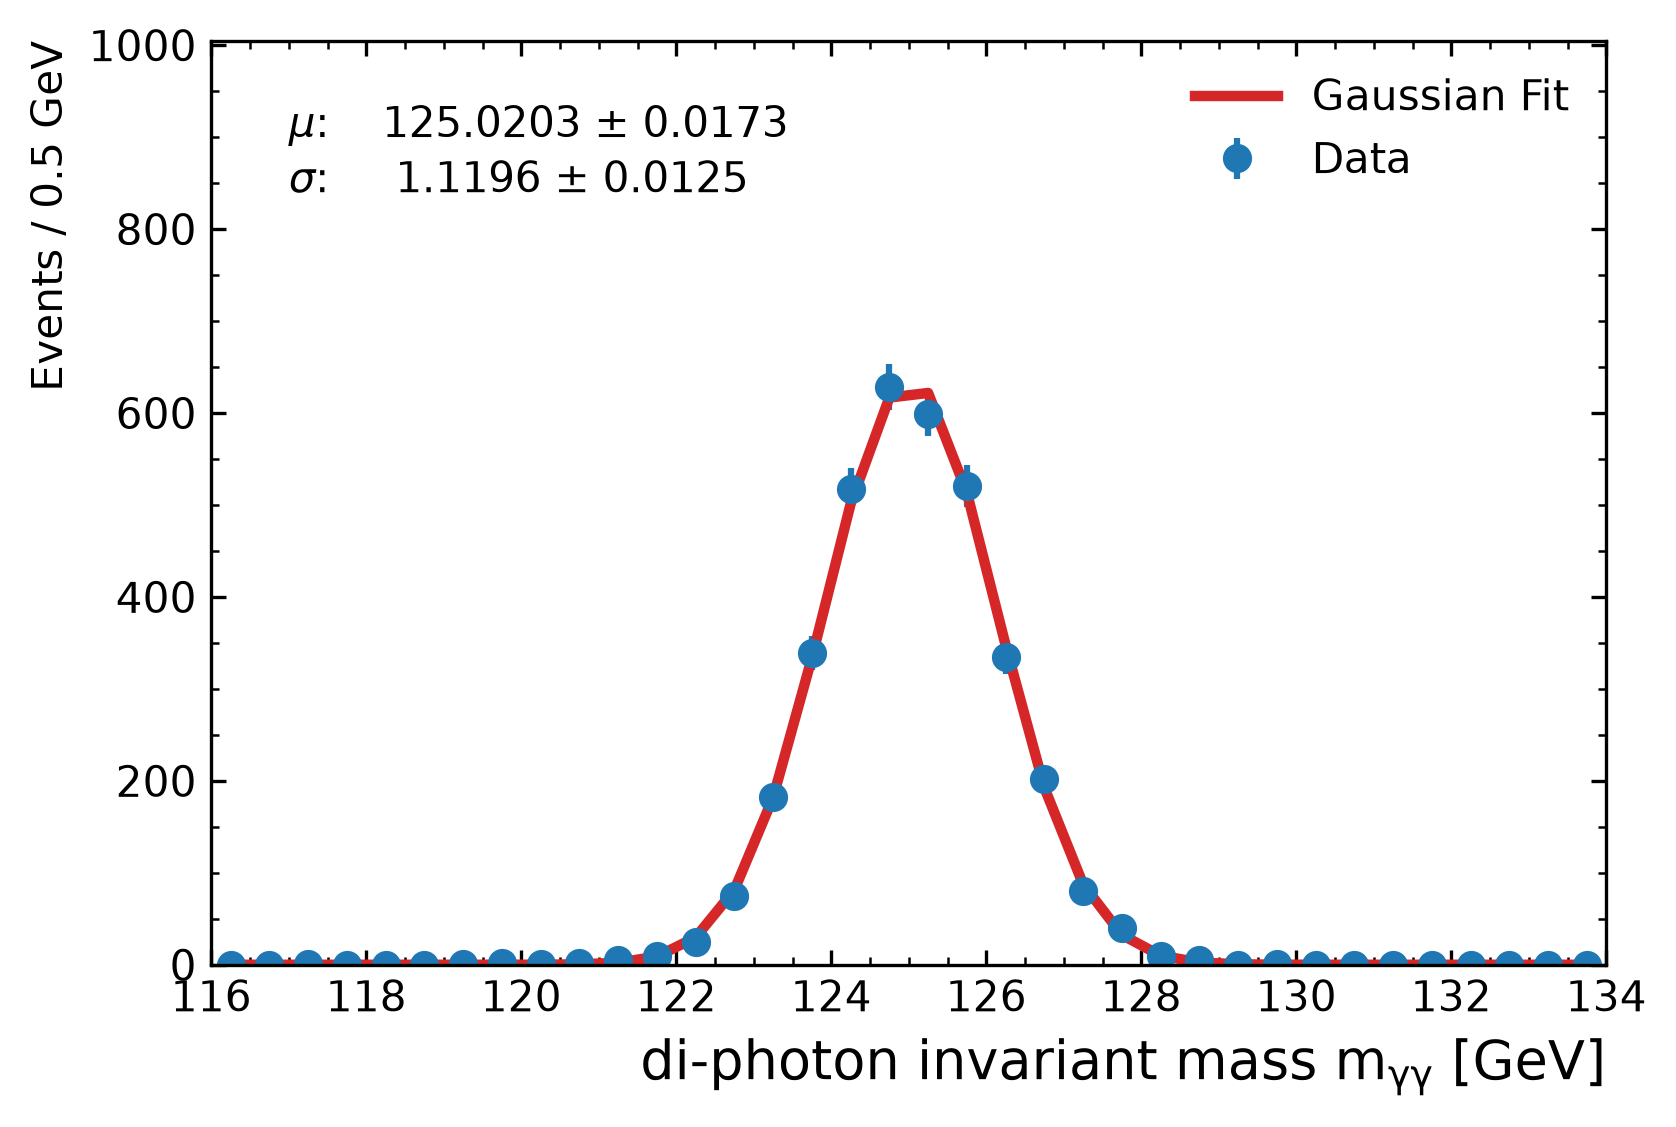

In [49]:
fit_color = '#d62728'  

# x-axis range of the plot
xmin = 116 #GeV
xmax = 134 #GeV

# Histogram bin setup
step_size = 0.5 #GeV
bins = np.arange(start=xmin, # The interval includes this value
                    stop=xmax+step_size, # The interval doesn't include this value
                    step=step_size ) # Spacing between values
bincenters = np.arange(start=xmin+step_size/2, # The interval includes this value
                        stop=xmax+step_size/2, # The interval doesn't include this value
                        step=step_size ) # Spacing between values

# Creating histogram from data
data_x,_ = np.histogram(ak.to_numpy(data_all),
                        bins=bins) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

# do the gaussian fit
gauss_fit = GaussianModel()
pars = gauss_fit.guess(data_x,x=bincenters,amplitude=100,center=125,sigma=2)

fit = gauss_fit.fit(data_x,pars,x=bincenters,weights=1/data_x_errors,nan_policy="omit")

# plot
plt.figure(figsize=(6,4),dpi=300)
ax = plt.gca() # get current axes

# plot the data points
ax.errorbar(x=bincenters, y=data_x, yerr=data_x_errors,
                    fmt='o', # 'k' means black and 'o' is for circles
                    color='#1f77b4',
                    label='Data')

# plot fit
ax.plot(bincenters, fit.best_fit, '-', color=fit_color, label="Gaussian Fit", linewidth=2.5)

# set the x-limit of the main axes
ax.set_xlim( left=xmin, right=xmax )

ax.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
ax.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

ax.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )
ax.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')
ax.set_ylim( bottom=0, top=np.amax(data_x)*1.6 )
ax.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
ax.legend( frameon=False ); # no box around the legend
plt.text(117,900,rf"$\mu$:    {mu:.4f} $\pm$ {mu_err:.4f}")
plt.text(117,840,rf"$\sigma$:     {sigma:.4f} $\pm$ {sigma_err:.4f}")

In [50]:
mu = fit.params["center"].value
sigma = fit.params["sigma"].value

# Access parameter standard errors (uncertainties from the covariance matrix)
mu_err = fit.params["center"].stderr
sigma_err = fit.params["sigma"].stderr

print(rf"$\mu$: {mu:.4f} +/- {mu_err:.4f}")
print(f"$\sigma$:     {sigma:.4f} +/- {sigma_err:.4f}")

# Chi-squared statistics
chi2 = fit.chisqr  # Total chi-squared
red_chi2 = fit.redchi  # Reduced chi-squared (chisqr / degrees of freedom)

# Degrees of freedom and data points
dof = fit.nfree  # Degrees of freedom (N_data - N_parameters)
ndata = fit.ndata  # Number of data points used in fit

# Model quality metrics
aic = fit.aic  # Akaike Information Criterion
bic = fit.bic  # Bayesian Information Criterion

print(f"Chi-Square (χ²):         {chi2:.4f}")
print(f"Reduced Chi-Square (χᵣ²): {red_chi2:.4f}")
print(f"Degrees of Freedom:      {dof}")
print(f"AIC:                     {aic:.4f}")
print(f"BIC:                     {bic:.4f}")

$\mu$: 125.0203 +/- 0.0173
$\sigma$:     1.1196 +/- 0.0125
Chi-Square (χ²):         16.1181
Reduced Chi-Square (χᵣ²): 0.8483
Degrees of Freedom:      19
AIC:                     -0.8442
BIC:                     2.4290
